# BKG Studies Test

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm


In [2]:
#parameters
# nfiles = -1
nfiles = 7
fw, fh = 16, 9

In [3]:
#processor
runner = processor.Runner(
    executor=processor.FuturesExecutor(),
    schema = llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

In [4]:
#channels: cuts to be applied (slections.yaml) 
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_2lj", "bkg_study_isopdisp_2lj_dPhi_4mu", "bkg_study_isopdisp_2lj_dPhi_2mu2e"]

ch1 = channels[0] # no cuts
ch2 = channels[1] # iso and disp
ch3 = channels[2] # 2lj
ch4 = channels[3] # 4mu channel
ch5 = channels[4] # 2mu2e channel
# ch6 = channels[5] # 4mu channel with .2mulj in objects

all_cha = [ch1, ch2, ch3, ch4, ch5]
all_cha_names = ["base", "Iso + Disp", ">2LJ", "4mu", "2mu2e"]

In [5]:
#runner
p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"],
)

In [6]:
# samples
# test 2mu
test2 = [
    # "2Mu2E_200GeV_5p0GeV_100p0mm",
    "2Mu2E_500GeV_5p0GeV_80p0mm",
    # "2Mu2E_800GeV_5p0GeV_50p0mm",
    # "2Mu2E_1000GeV_5p0GeV_40p0mm",
]


test4 = [        
        # "4Mu_500GeV_1p2GeV_0p019mm",
        # "4Mu_500GeV_1p2GeV_0p19mm",
        "4Mu_500GeV_1p2GeV_1p9mm",
        # "4Mu_500GeV_1p2GeV_9p6mm",
        # "4Mu_500GeV_1p2GeV_19p0mm",
]

In [7]:
# test 2mu
fileset_test2 = utilities.make_fileset(test2, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
out_test2 = runner.run(fileset_test2, treename="Events", processor_instance=p)
out_test2 = out_test2["out"]
coffea.util.save(out_test2, "outputs/BKG_test2.coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


2Mu2E_500GeV_5p0GeV_80p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [8]:
# test 4mu
fileset_test4 = utilities.make_fileset(test4,  "llpNanoAOD_v2", max_files = nfiles, location_cfg = "signal_4mu_v10.yaml")
out_test4 = runner.run(fileset_test4, treename="Events", processor_instance=p)
out_test4 = out_test4["out"]
coffea.util.save(out_test4, "outputs/BKG_test4.coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


4Mu_500GeV_1p2GeV_1p9mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [9]:
output_t2 = coffea.util.load("outputs/BKG_test2.coffea")
output_t4 = coffea.util.load("outputs/BKG_test4.coffea")
# output_t2[test2[0]]["cutflow"][ch5].print_table()
print()
# output_t2[test2[1]]["cutflow"][ch5].print_table()
print()
# output_t4[test4[4]]["cutflow"][ch4].print_table()
# output_t2

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


Text(0.5, 1.0, '4mu')

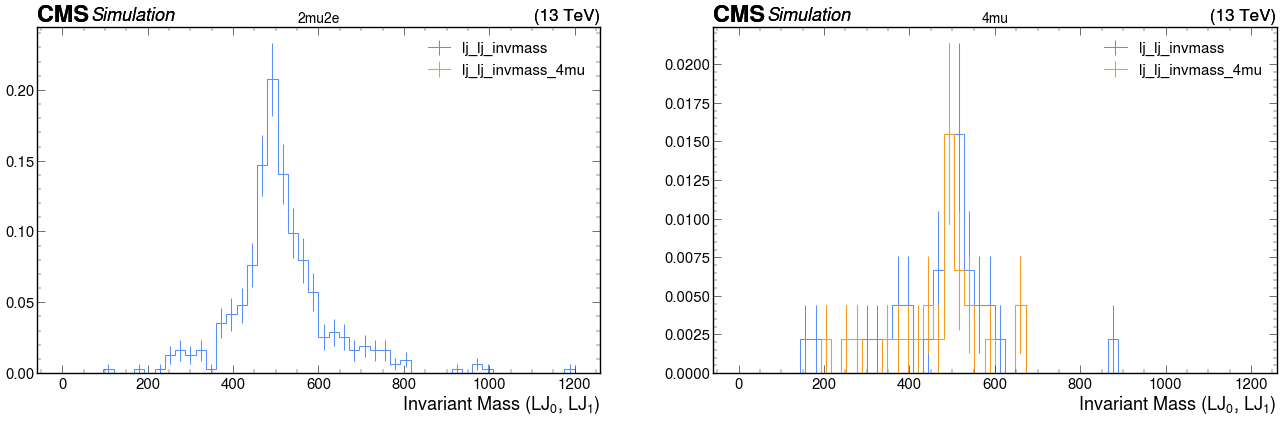

In [14]:
# plt.subplots(1, 1, figsize=(16, 9))
hist = ["lj_lj_invmass", "lj_lj_invmass_4mu"]
sss2 = test2[0]
sss4 = test4[0]

# for i, cha in enumerate(all_cha):
plt.subplots(1, 2, figsize=(32, 9))
plt.subplot(1, 2, 1)
utilities.plot(output_t2[sss2]["hists"][hist[0]][ch5, ::2j], label = hist[0], density=False,)
utilities.plot(output_t2[sss2]["hists"][hist[1]][ch5, ::2j], label = hist[1], density=False,)
plt.legend(alignment="left", loc=0)
plt.title("2mu2e", fontsize=20)
# plt.text(215, 0.1, sss2)

plt.subplot(1, 2, 2)
utilities.plot(output_t4[sss4]["hists"][hist[0]][ch4, ::2j], label = hist[0], density=False,)
utilities.plot(output_t4[sss4]["hists"][hist[1]][ch4, ::2j], label = hist[1], density=False,)
plt.legend(alignment="left", loc=0)
plt.title("4mu", fontsize=20)
# plt.text(215, 0.1, sss4)
    

In [11]:
# to test
npl =2

hist_2mu = ["mulj_egmlj_invmass"]
hist_4mu = ["lj_lj_invmass_4mu"]

plt.subplots(1, npl, figsize=(npl*16, 9))

# for hist in hist_2mu:
#     plt.subplot(1, 2, 1)
#     for sss in test2[:]:
#         utilities.plot(output_t2[sss]["hists"][hist][ch5, ::2j], label = sss, density=False,)
#     plt.legend(alignment="left", loc=0)
#     plt.title("2mu2e: Final cuts", fontsize=20)

# for hist in hist_4mu:
#     plt.subplot(1, 2, 2)
#     for sss in test4[:]:
#         utilities.plot(output_t4[sss]["hists"][hist][ch4, ::2j], label = sss, density=False,)
#         utilities.plot(output_t4[sss]["hists"][hist][ch4, ::2j], label = sss, density=False,)
#     plt.legend(alignment="left", loc=0)
#     plt.title("4mu: Final cuts", fontsize=20)
# plt.savefig(f"plots/BKG_test_invmass", bbox_inches="tight")

(<Figure size 1600x450 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

In [12]:
raise SystemExit("Notebook stopped intentionally after this cell.")

SystemExit: Notebook stopped intentionally after this cell.

/usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
